# CO544: Machine Learning and Data Mining
## Lab 03: Decision Trees and k-Nearest Neighbors Classification
### E/21/245

### Task 01 - Build two decision tree classifiers with Gini index and entropy


In [30]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


In [3]:
# Task 01 - Demonstrate how decision trees deal with missing values
wine_df = pd.read_csv('wine.csv')
wine_df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
# column renaming
new_column_names = [
    'wine_class', 'alcohol', 'malic_acid', 'ash', 'alcalinity',
    'magnesium', 'phenols', 'flavanoids', 'nonflavanoid_phenols',
    'proanth', 'color_intensity', 'hue', 'od280', 'proline'
]
wine_df.columns = new_column_names

In [37]:
print("Unique classes in target variable:")
print(wine_df['wine_class'].unique())

Unique classes in target variable:
[1 2 3]


/tmp/ipykernel_1797/2395816075.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='wine_class', data=wine_df, palette='Set2')


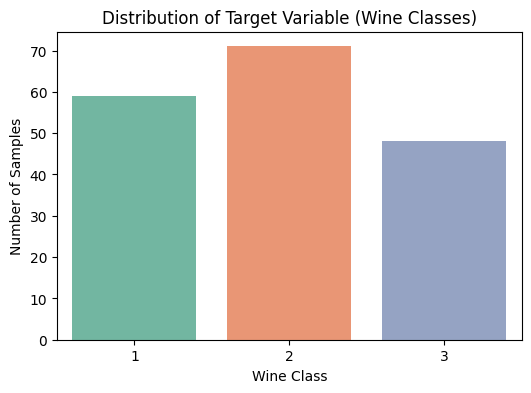

In [38]:
plt.figure(figsize=(6, 4))
sns.countplot(x='wine_class', data=wine_df, palette='Set2')
plt.title('Distribution of Target Variable (Wine Classes)')
plt.xlabel('Wine Class')
plt.ylabel('Number of Samples')
plt.show()

In [5]:
wine_df.columns.tolist()

['wine_class',
 'alcohol',
 'malic_acid',
 'ash',
 'alcalinity',
 'magnesium',
 'phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanth',
 'color_intensity',
 'hue',
 'od280',
 'proline']

In [29]:
wine_df.isnull().sum()

,0
wine_class,0
alcohol,0
malic_acid,0
ash,0
alcalinity,0
magnesium,0
phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanth,0


In [9]:
# duplicates
wine_df.duplicated().sum()

np.int64(0)

no duplicates

In [10]:
wine_df.shape[0]

178

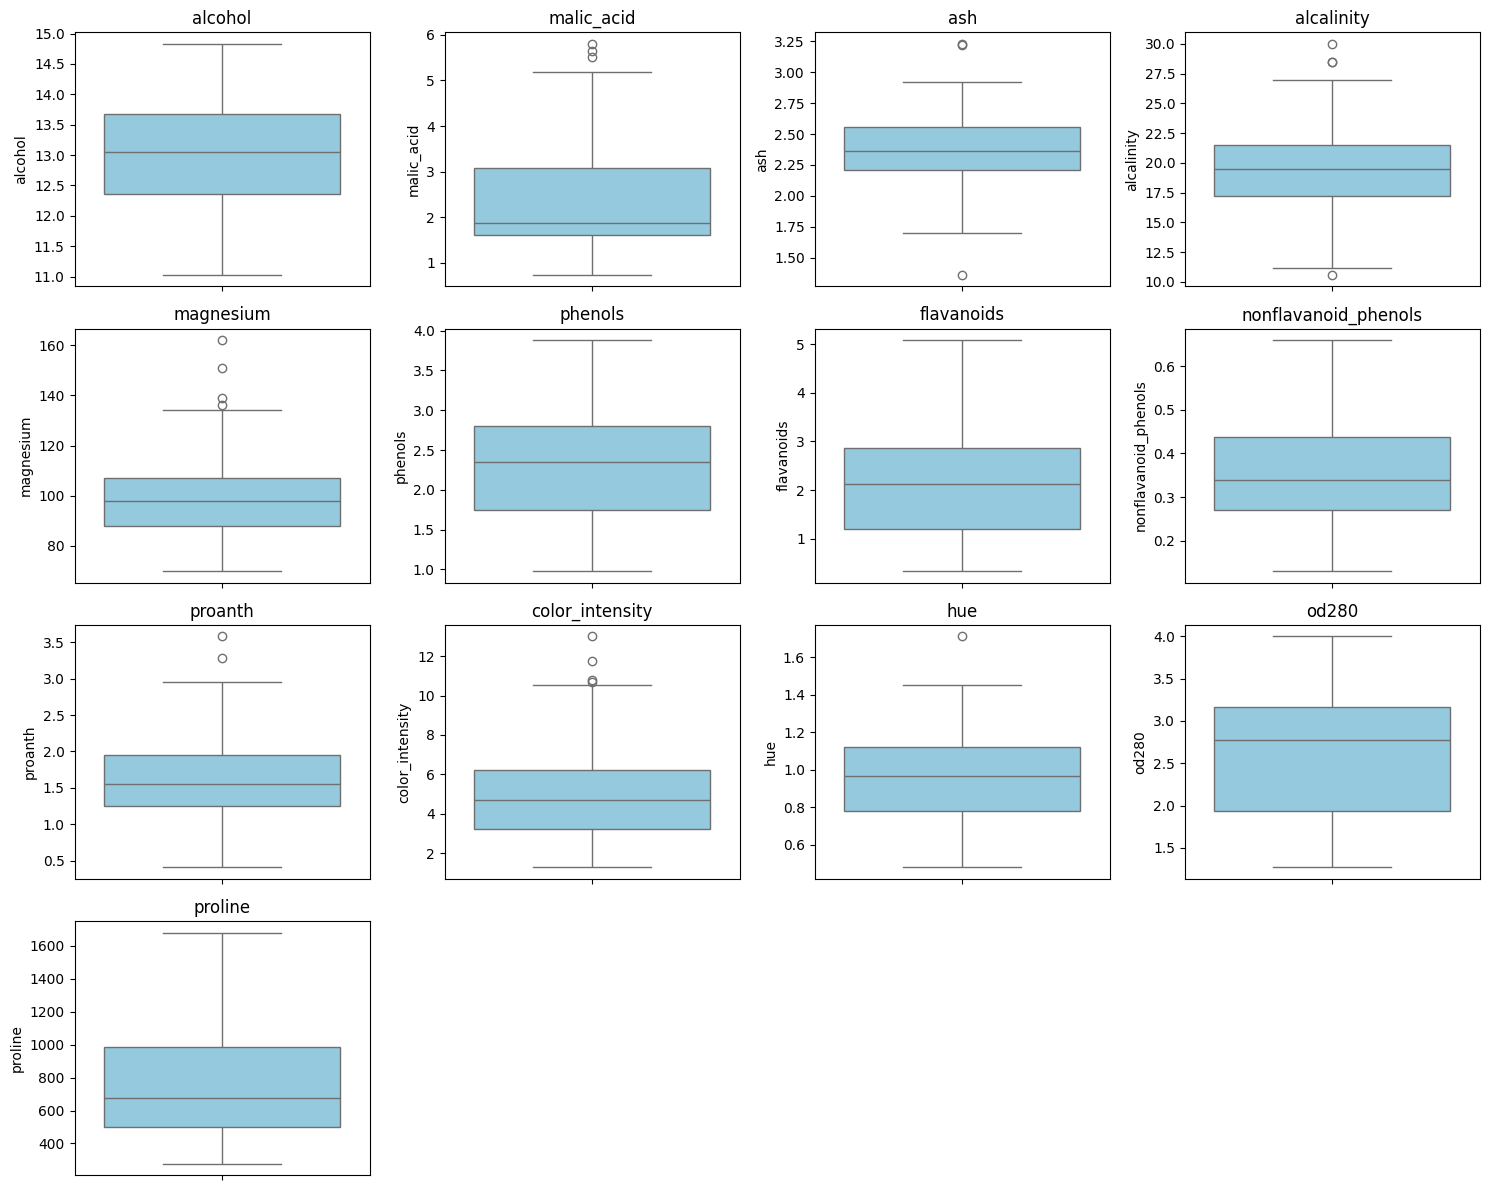

In [12]:
plt.figure(figsize=(15, 12))
features = wine_df.columns.drop('wine_class')


for i, col in enumerate(features):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=wine_df[col], color='skyblue')
    plt.title(col)
    plt.tight_layout()

plt.show()

In [13]:
def remove_outliers_iqr(df):
    df_out = df.copy()
    features = df_out.columns.drop('wine_class')
    for col in features:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_out = df_out[(df_out[col] >= lower_bound) & (df_out[col] <= upper_bound)]
    return df_out

In [15]:
wine_df_cleaned = remove_outliers_iqr(wine_df)
print(f"before remove outliers: {wine_df.shape[0]} | after remove outliers: {wine_df_cleaned.shape[0]}")

before remove outliers: 178 | after remove outliers: 161


In [16]:
# X, y
X = wine_df_cleaned.drop('wine_class', axis=1)
y = wine_df_cleaned['wine_class']

In [17]:
#Training (75%) , Testing (25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [20]:
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [21]:
y_pred_gini = clf_gini.predict(X_test)

In [24]:
# 1. Gini Criterion -> Decision Tree
accuracy_gini = metrics.accuracy_score(y_test, y_pred_gini)
print(f"Gini Model Accuracy: {accuracy_gini * 100:.2f}%")

Gini Model Accuracy: 87.80%


In [26]:
# 2. Entropy (Information Gain) -> Decision Tree
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [27]:
y_pred_entropy = clf_entropy.predict(X_test)
accuracy_entropy = metrics.accuracy_score(y_test, y_pred_entropy)
print(f"Entropy Model Accuracy: {accuracy_entropy * 100:.2f}%")

Entropy Model Accuracy: 92.68%


In [32]:
print(" GINI MODEL EVALUATION")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gini))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gini))


 GINI MODEL EVALUATION

Confusion Matrix:
[[17  0  0]
 [ 2 13  1]
 [ 2  0  6]]

Classification Report:
              precision    recall  f1-score   support

           1       0.81      1.00      0.89        17
           2       1.00      0.81      0.90        16
           3       0.86      0.75      0.80         8

    accuracy                           0.88        41
   macro avg       0.89      0.85      0.86        41
weighted avg       0.89      0.88      0.88        41



In [33]:

print(" ENTROPY MODEL EVALUATION")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_entropy))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_entropy))

 ENTROPY MODEL EVALUATION

Confusion Matrix:
[[17  0  0]
 [ 2 14  0]
 [ 0  1  7]]

Classification Report:
              precision    recall  f1-score   support

           1       0.89      1.00      0.94        17
           2       0.93      0.88      0.90        16
           3       1.00      0.88      0.93         8

    accuracy                           0.93        41
   macro avg       0.94      0.92      0.93        41
weighted avg       0.93      0.93      0.93        41



In [34]:
cm_gini = confusion_matrix(y_test, y_pred_gini)
cm_entropy = confusion_matrix(y_test, y_pred_entropy)
class_labels = ['Class 1', 'Class 2', 'Class 3']

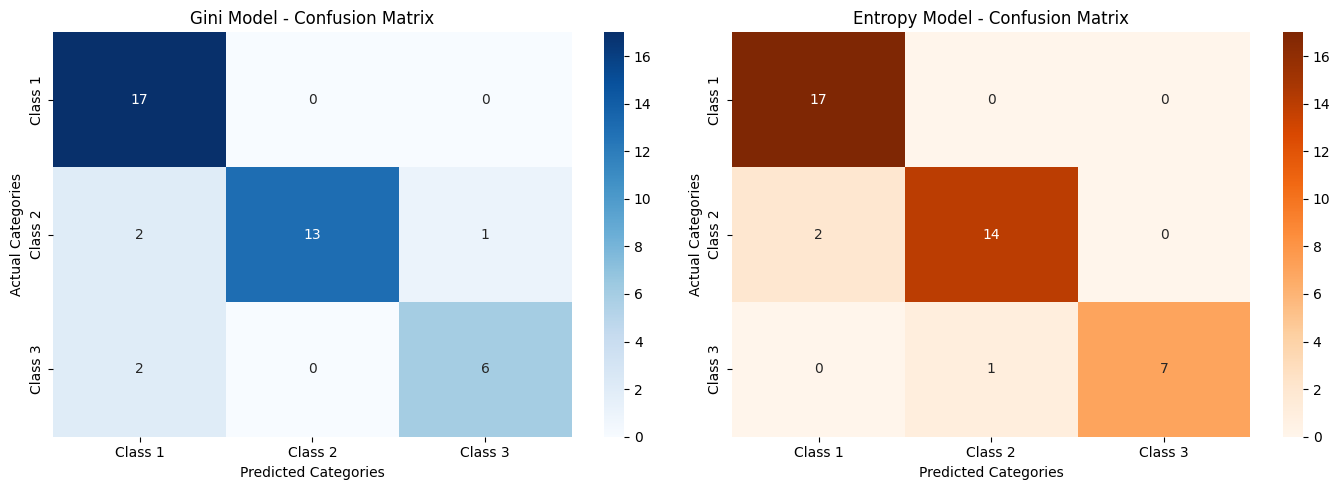

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gini Heatmap
sns.heatmap(cm_gini, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_title('Gini Model - Confusion Matrix')
axes[0].set_xlabel('Predicted Categories')
axes[0].set_ylabel('Actual Categories')

# 2. Entropy Heatmap
sns.heatmap(cm_entropy, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_title('Entropy Model - Confusion Matrix')
axes[1].set_xlabel('Predicted Categories')
axes[1].set_ylabel('Actual Categories')

plt.tight_layout()
plt.show()

In [41]:
# Task 1 (c): Overfitting -> Pruning
clf_pruned = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf_pruned.fit(X_train, y_train)

y_pred_pruned = clf_pruned.predict(X_test)

print("\n PRUNED MODEL - GINI (max_depth=3)")
print(f"Pruned Model Accuracy: {metrics.accuracy_score(y_test, y_pred_pruned) * 100:.2f}%")


 PRUNED MODEL - GINI (max_depth=3)
Pruned Model Accuracy: 90.24%


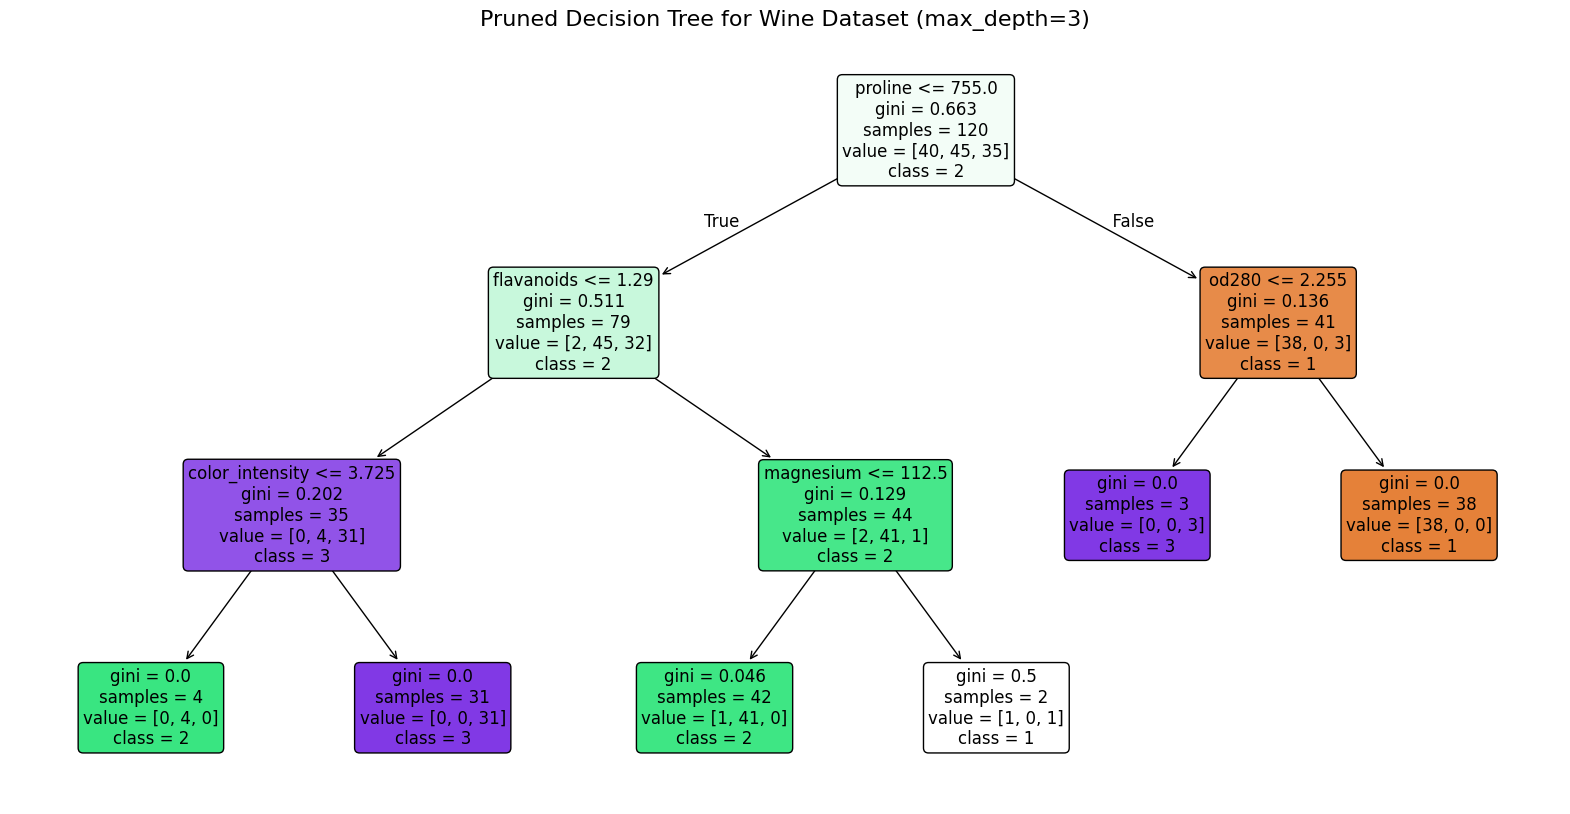

In [42]:
# see the tree
plt.figure(figsize=(20, 10))
plot_tree(
    clf_pruned,
    feature_names=X.columns,
    class_names=[str(c) for c in clf_pruned.classes_],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Pruned Decision Tree for Wine Dataset (max_depth=3)", fontsize=16)
plt.show()

### Task 02: Apply k-Nearest Neighbors to the same Wine.csv dataset

In [43]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [44]:
X = wine_df_cleaned.drop('wine_class', axis=1)
y = wine_df_cleaned['wine_class']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [47]:
# Task 2 (a): Preprocess with Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
display(X_train_scaled_df.head())

,alcohol,malic_acid,ash,alcalinity,magnesium,phenols,flavanoids,nonflavanoid_phenols,proanth,color_intensity,hue,od280,proline
0,0.248608,0.769414,-0.326839,-0.256854,-0.015567,-0.749379,-1.147346,2.110765,0.683293,2.494929,-1.771083,-1.460934,-0.193778
1,-1.731955,-0.341481,0.431456,0.748932,-1.152658,-0.502783,-0.269093,1.013533,-0.278093,-1.008902,0.203018,0.219287,-0.177619
2,-1.507740,-0.646081,-2.011940,0.067593,-0.990217,0.401404,-0.320154,0.085106,-0.148676,-1.344762,-0.066177,-0.200768,-1.034068
3,-0.972116,1.289027,-0.663860,-0.256854,1.121524,-1.439850,-1.198407,-0.590114,-0.666345,1.446503,-1.367290,-0.796976,0.387961
4,0.049306,-0.843175,-1.085135,-1.230194,-0.015567,0.237007,0.701071,-0.674517,-0.241117,-0.600425,1.010605,0.137986,0.921221


In [51]:
# Task 2 (b): Tune k and distance metric via Cross-Validation
param_grid = {
    'n_neighbors': list(range(1, 21)),                         # k = 1 to 20
    'metric': ['euclidean', 'manhattan']                       # Distance metrics
}

In [52]:
# 5-Fold Cross Validation to find the best parameter
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')

In [53]:
start_tune_time = time.time()
grid_search.fit(X_train_scaled, y_train)
end_tune_time = time.time()

In [54]:
best_k = grid_search.best_params_['n_neighbors']
best_metric = grid_search.best_params_['metric']

In [56]:
# Convert the grid search results into a clean DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

In [57]:
# Filter results by metric for plotting
euclidean_results = cv_results[cv_results['param_metric'] == 'euclidean']
manhattan_results = cv_results[cv_results['param_metric'] == 'manhattan']


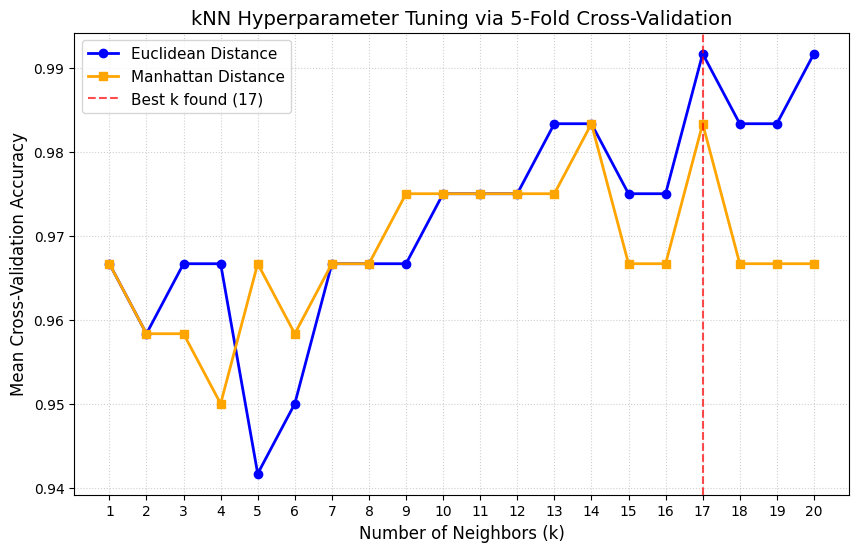

In [59]:
# Plotting
plt.figure(figsize=(10, 6))

# Plot line for Euclidean distance
plt.plot(euclidean_results['param_n_neighbors'], euclidean_results['mean_test_score'],
         marker='o', label='Euclidean Distance', color='blue', linewidth=2)

# Plot line for Manhattan distance
plt.plot(manhattan_results['param_n_neighbors'], manhattan_results['mean_test_score'],
         marker='s', label='Manhattan Distance', color='orange', linewidth=2)

# Highlight the best point found by GridSearchCV
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
            label=f'Best k found ({best_k})')

plt.title('kNN Hyperparameter Tuning via 5-Fold Cross-Validation', fontsize=14)
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Mean Cross-Validation Accuracy', fontsize=12)
plt.xticks(list(range(1, 21)))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

In [55]:
print(f"Best k: {best_k}")
print(f"Best Metric: {best_metric}")

Best k: 17
Best Metric: euclidean


In [60]:
# Task 2 (c): Final kNN Model Execution & Evaluation
best_knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)

In [61]:
start_train_time = time.time()
best_knn.fit(X_train_scaled, y_train)
y_pred_knn = best_knn.predict(X_test_scaled)
end_train_time = time.time()

In [62]:
knn_runtime = end_train_time - start_train_time
knn_accuracy = accuracy_score(y_test, y_pred_knn)

In [63]:
print(f"\nkNN Model Accuracy: {knn_accuracy * 100:.2f}%")
print(f"kNN Inference Runtime: {knn_runtime:.6f} seconds")
print("\n--- kNN Classification Report ---")
print(classification_report(y_test, y_pred_knn))


kNN Model Accuracy: 100.00%
kNN Inference Runtime: 0.037814 seconds

--- kNN Classification Report ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        17
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00         8

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



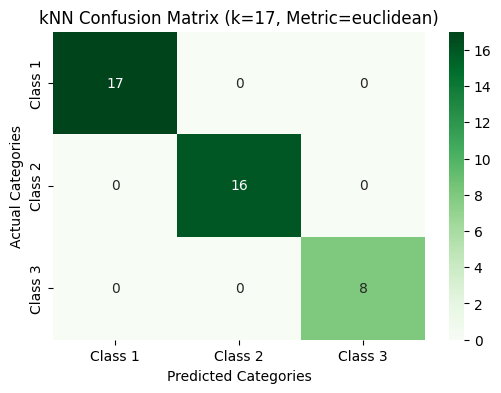

In [64]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 1', 'Class 2', 'Class 3'])
plt.title(f'kNN Confusion Matrix (k={best_k}, Metric={best_metric})')
plt.xlabel('Predicted Categories')
plt.ylabel('Actual Categories')
plt.show()

In [65]:
train_acc = best_knn.score(X_train_scaled, y_train)
test_acc = best_knn.score(X_test_scaled, y_test)
print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Testing Accuracy: {test_acc * 100:.2f}%")

Training Accuracy: 98.33%
Testing Accuracy: 100.00%


Not overfitting here
